Data Loaded : (9744, 13)

Contoh hasil cleaning:
0                         [tea, paper_towels, spinach]
1                              [salmon, shaving_cream]
2                                   [mustard, dustpan]
3    [shrimp, iron, cleaning_spray, toilet_paper, p...
4                                      [broom, cereal]
Name: Product, dtype: object


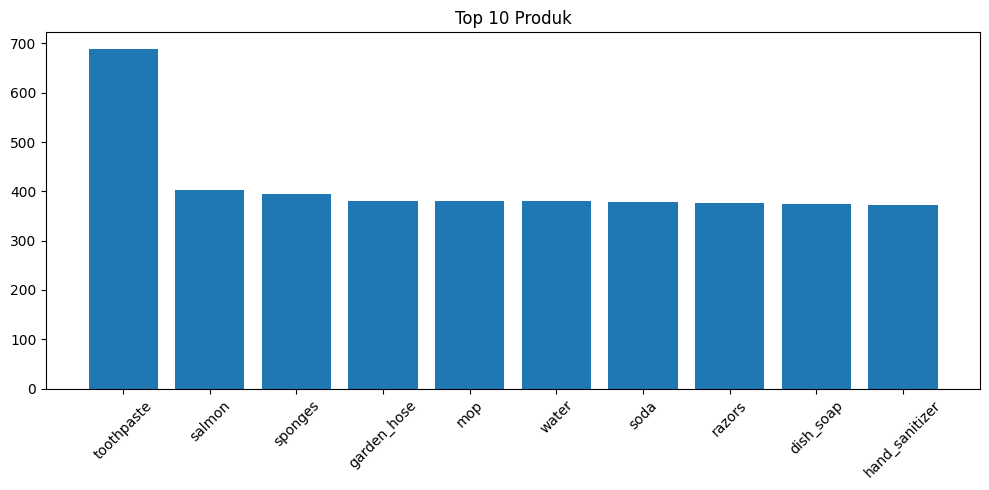

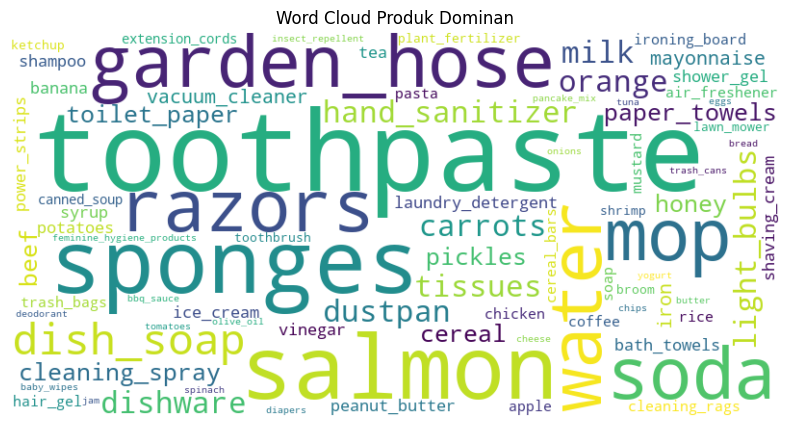


TF-IDF Shape:
(9744, 81)

=== CONTOH TF-IDF ===
   air_freshener  apple  baby_wipes  banana  bath_towels  bbq_sauce  beef  \
0            0.0    0.0         0.0     0.0          0.0        0.0   0.0   
1            0.0    0.0         0.0     0.0          0.0        0.0   0.0   
2            0.0    0.0         0.0     0.0          0.0        0.0   0.0   
3            0.0    0.0         0.0     0.0          0.0        0.0   0.0   
4            0.0    0.0         0.0     0.0          0.0        0.0   0.0   

   bread     broom  butter  ...  tomatoes  toothbrush  toothpaste  trash_bags  \
0    0.0  0.000000     0.0  ...       0.0         0.0         0.0         0.0   
1    0.0  0.000000     0.0  ...       0.0         0.0         0.0         0.0   
2    0.0  0.000000     0.0  ...       0.0         0.0         0.0         0.0   
3    0.0  0.000000     0.0  ...       0.0         0.0         0.0         0.0   
4    0.0  0.712428     0.0  ...       0.0         0.0         0.0         0.0   

 

In [2]:
# =========================================
# IMPORT LIBRARY
# =========================================

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from collections import Counter
from wordcloud import WordCloud
import ast


# =========================================
# LOAD DATA
# =========================================

df = pd.read_excel(
    "C:/Users/LENOVO/Downloads/data_kategorikal_newyork.xlsx"
)

df.columns = df.columns.str.strip()

print("Data Loaded :", df.shape)


# =========================================
# PREPROCESSING PRODUCT
# =========================================

def clean_product(x):

    try:
        items = ast.literal_eval(str(x))

    except:
        x = str(x).replace("[", "")
        x = x.replace("]", "")
        x = x.replace("'", "")
        items = x.split(",")

    items = [
        i.strip().lower().replace(" ", "_")
        for i in items
        if i.strip() != ""
    ]

    # menghapus duplikat tanpa mengacak urutan
    return list(dict.fromkeys(items))


df["Product"] = df["Product"].apply(clean_product)

df = df[df["Product"].map(len) > 0]

print("\nContoh hasil cleaning:")
print(df["Product"].head())


# =========================================
# FEATURE REPRESENTATION
# =========================================

df["transaction_text"] = df["Product"].apply(
    lambda x: " ".join(x)
)


# =========================================
# VISUALISASI TOP 10 PRODUK
# =========================================

all_products = [
    item
    for sublist in df["Product"]
    for item in sublist
]

top10 = Counter(all_products).most_common(10)

labels, values = zip(*top10)

plt.figure(figsize=(10, 5))
plt.bar(labels, values)
plt.xticks(rotation=45)
plt.title("Top 10 Produk")
plt.tight_layout()
plt.show()


# =========================================
# WORDCLOUD
# =========================================

text_for_wordcloud = " ".join(all_products)

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(text_for_wordcloud)

plt.figure(figsize=(12, 5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud Produk Dominan")
plt.show()


# =========================================
# TF-IDF
# =========================================

tfidf = TfidfVectorizer()

tfidf_matrix = tfidf.fit_transform(
    df["transaction_text"]
)

print("\nTF-IDF Shape:")
print(tfidf_matrix.shape)

tfidf_df = pd.DataFrame(
    tfidf_matrix.toarray(),
    columns=tfidf.get_feature_names_out()
)

print("\n=== CONTOH TF-IDF ===")
print(tfidf_df.head())


# =========================================
# COSINE SIMILARITY ANTAR PRODUK
# =========================================

product_matrix = tfidf_matrix.T

similarity = cosine_similarity(product_matrix)

product_names = tfidf.get_feature_names_out()

product_index = {
    p: i
    for i, p in enumerate(product_names)
}

print("\nJumlah Produk:")
print(len(product_names))


# =========================================
# SUBCATEGORY MAP
# =========================================

subcategory_map = {

    # FRUIT
    "apple": "fruit",
    "banana": "fruit",
    "orange": "fruit",

    # VEGETABLE
    "carrots": "vegetable",
    "onions": "vegetable",
    "spinach": "vegetable",
    "potatoes": "vegetable",
    "tomatoes": "vegetable",

    # DAIRY
    "milk": "dairy",
    "cheese": "dairy",
    "yogurt": "dairy",
    "butter": "dairy",
    "ice_cream": "dairy",

    # PROTEIN
    "eggs": "protein",
    "chicken": "protein",
    "beef": "protein",
    "salmon": "protein",
    "shrimp": "protein",
    "tuna": "protein",

    # GRAIN
    "bread": "grain",
    "rice": "grain",
    "pasta": "grain",
    "cereal": "grain",
    "cereal_bars": "grain",
    "pancake_mix": "grain",
    "canned_soup": "grain",

    # BEVERAGE
    "coffee": "beverage",
    "tea": "beverage",
    "soda": "beverage",
    "water": "beverage",

    # CONDIMENT
    "honey": "condiment",
    "jam": "condiment",
    "ketchup": "condiment",
    "mustard": "condiment",
    "mayonnaise": "condiment",
    "olive_oil": "condiment",
    "vinegar": "condiment",
    "peanut_butter": "condiment",
    "bbq_sauce": "condiment",
    "pickles": "condiment",
    "syrup": "condiment",

    # SNACK
    "chips": "snack",

    # CLEANING TOOLS
    "broom": "cleaning_tools",
    "mop": "cleaning_tools",
    "vacuum_cleaner": "cleaning_tools",
    "dustpan": "cleaning_tools",

    # CLEANING SOLUTION
    "cleaning_spray": "cleaning_solution",
    "dish_soap": "cleaning_solution",
    "soap": "cleaning_solution",
    "laundry_detergent": "cleaning_solution",

    # CLEANING ACCESSORIES
    "sponges": "cleaning_accessories",
    "cleaning_rags": "cleaning_accessories",
    "dishware": "cleaning_accessories",

    # PAPER PRODUCTS
    "paper_towels": "paper_products",
    "toilet_paper": "paper_products",
    "tissues": "paper_products",

    # WASTE MANAGEMENT
    "trash_bags": "waste_management",
    "trash_cans": "waste_management",

    # HOME FRESHENER
    "air_freshener": "home_freshener",

    # HAIR CARE
    "shampoo": "hair_care",
    "hair_gel": "hair_care",

    # ORAL CARE
    "toothpaste": "oral_care",
    "toothbrush": "oral_care",

    # SHAVING
    "razors": "shaving",
    "shaving_cream": "shaving",

    # BODY CARE
    "deodorant": "body_care",
    "shower_gel": "body_care",
    "insect_repellent": "body_care",
    "bath_towels":"body_care",
    # HYGIENE
    "hand_sanitizer": "hygiene",
    "feminine_hygiene_products": "hygiene",
    "baby_wipes": "hygiene",
    "diapers": "hygiene",

    # ELECTRICAL
    "light_bulbs": "electrical",
    "extension_cords": "electrical",
    "power_strips": "electrical",

    # GARDEN
    "garden_hose": "garden",
    "lawn_mower": "garden",
    "plant_fertilizer": "garden",

    # LAUNDRY TOOLS
    "iron": "laundry_tools",
    "ironing_board": "laundry_tools"
}


# =========================================
# FUNGSI CATEGORY DAN SUBCATEGORY
# =========================================

def get_category(product):

    food = [
        "fruit", "vegetable", "dairy",
        "protein", "grain", "beverage",
        "condiment", "snack"
    ]

    cleaning = [
        "cleaning_tools", "cleaning_solution",
        "cleaning_accessories", "paper_products",
        "waste_management", "home_freshener"
    ]

    personal = [
        "hair_care", "oral_care", "shaving",
        "body_care", "hygiene"
    ]

    household = [
        "electrical", "garden", "laundry_tools"
    ]

    sub = subcategory_map.get(product, "other")

    if sub in food:
        return "food"

    elif sub in cleaning:
        return "cleaning"

    elif sub in personal:
        return "personal"

    elif sub in household:
        return "household"

    else:
        return "other"


def get_subcategory(product):

    return subcategory_map.get(product, "other")


# =========================================
# REKOMENDASI HYBRID
# CONTENT-BASED FILTERING
# TF-IDF + COSINE SIMILARITY + CATEGORY BONUS
# =========================================

def recommend_product(product_name, top_n=5):

    product_name = (
        product_name
        .lower()
        .replace(" ", "_")
    )

    if product_name not in product_index:
        return "Produk tidak ditemukan"

    idx = product_index[product_name]

    base_category = get_category(product_name)
    base_subcategory = get_subcategory(product_name)

    sim_scores = list(enumerate(similarity[idx]))

    results = []

    for i, score in sim_scores:

        prod = product_names[i]

        if prod == product_name:
            continue

        if score <= 0:
            continue

        prod_category = get_category(prod)
        prod_subcategory = get_subcategory(prod)

        # level prioritas
        # 2 = subcategory sama
        # 1 = category sama
        # 0 = beda kategori
        if prod_subcategory == base_subcategory:
            priority = 2
            final_score = score + 0.03

        elif prod_category == base_category:
            priority = 1
            final_score = score + 0.015

        else:
            priority = 0
            final_score = score

        results.append(
            (
                prod.replace("_", " "),
                prod_category,
                prod_subcategory,
                score,
                final_score,
                priority
            )
        )

    results = sorted(
        results,
        key=lambda x: (x[5], x[4]),
        reverse=True
    )

    results = results[:top_n]

    result_df = pd.DataFrame(
        results,
        columns=[
            "Product",
            "Category",
            "SubCategory",
            "Similarity",
            "Final Score",
            "Priority"
        ]
    )

    return result_df.drop(columns=["Priority"])


# =========================================
# EVALUASI MODEL
# =========================================

def evaluate_recommendation_model(top_n=5):

    total_product = 0
    total_recommended = 0

    precision_scores = []
    avg_similarity_scores = []
    category_match_scores = []
    subcategory_match_scores = []

    for product in product_names:

        rekomendasi = recommend_product(product, top_n=top_n)

        if isinstance(rekomendasi, str):
            continue

        if rekomendasi.empty:
            continue

        total_product += 1
        total_recommended += len(rekomendasi)

        original_category = get_category(product)
        original_subcategory = get_subcategory(product)

        category_match = rekomendasi[
            rekomendasi["Category"] == original_category
        ]

        subcategory_match = rekomendasi[
            rekomendasi["SubCategory"] == original_subcategory
        ]

        precision_at_k = len(category_match) / top_n
        category_match_ratio = len(category_match) / len(rekomendasi)
        subcategory_match_ratio = len(subcategory_match) / len(rekomendasi)
        avg_similarity = rekomendasi["Similarity"].mean()

        precision_scores.append(precision_at_k)
        category_match_scores.append(category_match_ratio)
        subcategory_match_scores.append(subcategory_match_ratio)
        avg_similarity_scores.append(avg_similarity)

    evaluation_result = {
        "Jumlah Produk Dievaluasi": total_product,
        "Total Rekomendasi Dihasilkan": total_recommended,
        "Precision@K": sum(precision_scores) / len(precision_scores),
        "Average Similarity": sum(avg_similarity_scores) / len(avg_similarity_scores),
        "Category Match Ratio": sum(category_match_scores) / len(category_match_scores),
        "Subcategory Match Ratio": sum(subcategory_match_scores) / len(subcategory_match_scores)
    }

    return pd.DataFrame(
        evaluation_result.items(),
        columns=["Metrik Evaluasi", "Nilai"]
    )


# =========================================
# TESTING REKOMENDASI
# =========================================

print("\n=== MILK ===")
print(recommend_product("milk", top_n=10))

print("\n=== CARROTS ===")
print(recommend_product("carrots", top_n=5))

print("\n=== SHAMPOO ===")
print(recommend_product("shampoo", top_n=5))

print("\n=== SOAP ===")
print(recommend_product("soap", top_n=5))


# =========================================
# HASIL EVALUASI MODEL
# =========================================

eval_result = evaluate_recommendation_model(top_n=5)

print("\n=== HASIL EVALUASI MODEL ===")
print(eval_result)